# Module 2 — So sánh các phương pháp biểu diễn văn bản

**Vietnamese Graph RAG · NLP Final Project**

Notebook này tái hiện **Thí nghiệm 1 + 1b** trong báo cáo:
1. **TF-IDF** (Lec02 — baseline thống kê)
2. **Word2Vec** skip-gram + negative sampling (Lec02 — tự train bằng PyTorch, không cần `gensim`)
3. **GloVe-SVD** (Lec02 — xấp xỉ qua SVD trên ma trận PPMI)
4. **PhoBERT** mean-pool (Lec06 — contextual, tiếng Việt SOTA)
5. **Keyword baseline** (đối chiếu — mô phỏng search sàn TMĐT)

Đánh giá: **Precision@5, Precision@10, MRR** + **bootstrap 95% CI** trên cùng 100 truy vấn, pool 10.9k review.

> **CPU-friendly**: PhoBERT encode 10.9k review ~30-60 phút CPU. Nếu đã có `artifacts/doc_vectors.npy` thì notebook sẽ load lại.

## 0. Thiết lập

In [7]:
import os, sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from vngraphrag.core.data import (
    ASPECTS, ASPECT_KEYWORDS, load_visfd, parse_label,
    preprocess_vietnamese, aspects_from_text,
)
from underthesea import word_tokenize

def seg(text):
    """PhoBERT input nên đã tách từ, giữ dấu/số."""
    return word_tokenize(str(text)[:256], format='text')

np.random.seed(42)
print('ROOT =', ROOT)

ROOT = /content/vietnamese-graph-rag


## 1. Load corpus (UIT-ViSFD train, 7,786 review)

In [8]:
df = load_visfd(str(ROOT / 'data' / 'raw'), filename='Train.csv')
# load_visfd đã tự parse_label + thêm cột aspects + brand
df['clean'] = df['comment'].apply(preprocess_vietnamese)
df = df[df['clean'].str.len() > 5].reset_index(drop=True)
print(f'Corpus: {len(df)} reviews')
print('Phân bố aspect:')
for a, c in Counter(a for lst in df['aspects'] for a in lst).most_common():
    print(f'  {a:12s} {c}')
df.head(3)

Corpus: 7786 reviews
Phân bố aspect:
  GENERAL      4866
  PERFORMANCE  4140
  BATTERY      3604
  FEATURES     2642
  CAMERA       2146
  PRICE        2061
  SER&ACC      1995
  DESIGN       1378
  SCREEN       949
  STORAGE      91


,index,comment,n_star,date_time,label,parsed_labels,aspects,brand,clean
0,0,Mới mua máy này Tại thegioididong thốt nốt cảm...,5,2 tuần trước,{CAMERA#Positive};{FEATURES#Positive};{BATTERY...,"[(CAMERA, Positive), (FEATURES, Positive), (BA...","[CAMERA, FEATURES, BATTERY, PRICE, GENERAL, SE...",Unknown,mới mua máy thegioididong thốt nốt cảm_thấy ok...
1,1,Pin kém còn lại miễn chê mua 8/3/2019 tình trạ...,5,14/09/2019,{BATTERY#Negative};{GENERAL#Positive};{OTHERS};,"[(BATTERY, Negative), (GENERAL, Positive)]","[BATTERY, GENERAL]",Unknown,pin kém miễn_chê mua tình_trạng pin ai giống
2,2,Sao lúc gọi điện thoại màn hình bị chấm nhỏ nh...,3,17/08/2020,{FEATURES#Negative};,"[(FEATURES, Negative)]",[FEATURES],Unknown,sao lúc gọi điện_thoại màn_hình chấm nhỏ nháy ...


## 2. Bộ truy vấn đánh giá (100 câu, 10 câu/aspect)

Phương án: lấy ngẫu nhiên 10 review/aspect làm câu truy vấn (nội dung review hay chứa từ khoá aspect → mô phỏng câu hỏi giàu từ khoá). Phán quyết: review *liên quan* nếu nhãn vàng chứa aspect đó.

In [9]:
rng = np.random.default_rng(42)
queries = []  # [(query_text, target_aspect)]
for asp in ASPECTS:
    pool = df[df['aspects'].apply(lambda a: asp in a)].index.tolist()
    pick = rng.choice(pool, size=min(10, len(pool)), replace=False)
    for i in pick:
        queries.append((df.loc[i, 'comment'][:120], asp))
print(f'#queries = {len(queries)}')

# ground-truth: doc d liên quan với query nhắm aspect alpha nếu alpha ∈ gold(d)
gold_aspects = df['aspects'].tolist()
def is_relevant(doc_idx, target):
    return target in gold_aspects[doc_idx]

#queries = 100


## 3. Hàm đánh giá: P@k, MRR + bootstrap CI

In [10]:
def evaluate(ranker, queries, k_list=(5, 10), n_boot=2000):
    """ranker(query_text) -> mảng index xếp hạng giảm dần. Trả P@k, MRR + 95% CI MRR."""
    per_q = []
    for q, tgt in queries:
        order = ranker(q)
        rels = [is_relevant(int(i), tgt) for i in order[:max(k_list)]]
        rr = 0.0
        for r, ok in enumerate(rels, 1):
            if ok:
                rr = 1.0 / r
                break
        per_q.append({'p@5': np.mean(rels[:5]), 'p@10': np.mean(rels[:10]), 'rr': rr})
    pq = pd.DataFrame(per_q)
    out = {'P@5': pq['p@5'].mean(), 'P@10': pq['p@10'].mean(), 'MRR': pq['rr'].mean()}
    # bootstrap CI cho MRR
    rr = pq['rr'].values
    rng = np.random.default_rng(0)
    boot = [rng.choice(rr, size=len(rr), replace=True).mean() for _ in range(n_boot)]
    out['MRR_CI'] = (float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5)))
    return out

results = {}

## 4. Baseline: Keyword (đếm token trùng)

In [11]:
import re as _re
doc_tokens = [set(_re.findall(r'\w+', c.lower())) for c in df['clean']]
def rank_keyword(q):
    qt = set(_re.findall(r'\w+', q.lower()))
    scores = np.array([len(qt & dt) for dt in doc_tokens])
    return np.argsort(-scores)

results['Keyword'] = evaluate(rank_keyword, queries)
print(results['Keyword'])

{'P@5': np.float64(0.674), 'P@10': np.float64(0.6300000000000001), 'MRR': np.float64(0.995), 'MRR_CI': (0.985, 1.0)}


## 5. TF-IDF (Lec02)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(max_features=10000)
M = tfidf.fit_transform(df['clean'].tolist())
print('TF-IDF matrix:', M.shape)

def rank_tfidf(q):
    qv = tfidf.transform([preprocess_vietnamese(q)])
    s = cosine_similarity(qv, M).ravel()
    return np.argsort(-s)

results['TF-IDF'] = evaluate(rank_tfidf, queries)
print(results['TF-IDF'])

TF-IDF matrix: (7786, 10000)
{'P@5': np.float64(0.526), 'P@10': np.float64(0.49500000000000005), 'MRR': np.float64(0.995), 'MRR_CI': (0.985, 1.0)}


## 6. Word2Vec — skip-gram + negative sampling (PyTorch)

Tự train trực tiếp bằng PyTorch (không cần `gensim`, build OK trên Python 3.12+). Mỗi câu được tách bằng `underthesea`; mỗi từ + ngữ cảnh cửa sổ 5.

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

# tokenize từ clean text
sentences = [c.split() for c in df['clean']]
vocab = Counter(w for s in sentences for w in s)
min_count = 5
itos = [w for w, c in vocab.most_common() if c >= min_count]
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)
print(f'Vocab = {V}')

WIN, EMB, NEG = 5, 100, 5
pairs = []
for s in sentences:
    ids = [stoi[w] for w in s if w in stoi]
    for i, c in enumerate(ids):
        for j in range(max(0, i-WIN), min(len(ids), i+WIN+1)):
            if i != j:
                pairs.append((c, ids[j]))
pairs = np.array(pairs, dtype=np.int64)
print('#pairs =', len(pairs))

freqs = np.array([vocab[w]**0.75 for w in itos]); freqs /= freqs.sum()

class SkipGram(nn.Module):
    def __init__(self, V, d):
        super().__init__()
        self.in_emb = nn.Embedding(V, d)
        self.out_emb = nn.Embedding(V, d)
        nn.init.uniform_(self.in_emb.weight, -0.5/d, 0.5/d)
        nn.init.zeros_(self.out_emb.weight)
    def forward(self, c, p, n):
        ve = self.in_emb(c)
        vp = self.out_emb(p)
        vn = self.out_emb(n)
        pos = torch.sigmoid((ve * vp).sum(-1)).clamp(1e-7, 1-1e-7).log()
        neg = torch.sigmoid(-(ve.unsqueeze(1) * vn).sum(-1)).clamp(1e-7, 1-1e-7).log().sum(-1)
        return -(pos + neg).mean()

model = SkipGram(V, EMB).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
BS = 4096
EPOCHS = 2
rng_np = np.random.default_rng(0)
for ep in range(EPOCHS):
    perm = rng_np.permutation(len(pairs))
    losses = []
    for i in range(0, len(perm), BS):
        batch = pairs[perm[i:i+BS]]
        c = torch.tensor(batch[:, 0], device=device)
        p = torch.tensor(batch[:, 1], device=device)
        n = torch.tensor(rng_np.choice(V, size=(len(batch), NEG), p=freqs), device=device)
        loss = model(c, p, n)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    print(f'epoch {ep+1}/{EPOCHS}  loss={np.mean(losses):.4f}')

W = model.in_emb.weight.detach().cpu().numpy()

def w2v_doc_vec(text):
    vs = [W[stoi[w]] for w in text.split() if w in stoi]
    return np.mean(vs, axis=0) if vs else np.zeros(EMB)

doc_w2v = np.vstack([w2v_doc_vec(c) for c in df['clean']])
def rank_w2v(q):
    qv = w2v_doc_vec(preprocess_vietnamese(q))
    s = doc_w2v @ qv / (np.linalg.norm(doc_w2v, axis=1) * np.linalg.norm(qv) + 1e-9)
    return np.argsort(-s)

results['Word2Vec'] = evaluate(rank_w2v, queries)
print(results['Word2Vec'])

device = cuda
Vocab = 2302
#pairs = 1453422
epoch 1/2  loss=2.5942
epoch 2/2  loss=2.4338
{'P@5': np.float64(0.6099999999999999), 'P@10': np.float64(0.5660000000000001), 'MRR': np.float64(0.9217619047619047), 'MRR_CI': (0.8696166666666667, 0.965)}


## 7. GloVe-SVD — xấp xỉ qua SVD trên ma trận PPMI

Đúng như báo cáo khai báo trung thực: **không phải GloVe gốc** mà là LSA/SVD trên ma trận đồng xuất hiện (PPMI). Mục tiêu: bằng chứng count-based ngữ nghĩa toàn cục.

In [14]:
from scipy import sparse
from scipy.sparse.linalg import svds

# ma trận co-occurrence từ - từ với cửa sổ 5
rows, cols = [], []
for s in sentences:
    ids = [stoi[w] for w in s if w in stoi]
    for i, c in enumerate(ids):
        for j in range(max(0, i-WIN), min(len(ids), i+WIN+1)):
            if i != j:
                rows.append(c); cols.append(ids[j])
C = sparse.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(V, V)).tocsr()
# PPMI
row_sum = np.array(C.sum(axis=1)).ravel() + 1e-9
col_sum = np.array(C.sum(axis=0)).ravel() + 1e-9
total = C.sum()
C_coo = C.tocoo()
vals = np.log((C_coo.data * total) / (row_sum[C_coo.row] * col_sum[C_coo.col]) + 1e-9)
vals = np.maximum(vals, 0)
PPMI = sparse.coo_matrix((vals, (C_coo.row, C_coo.col)), shape=(V, V)).tocsr()
U, S, _ = svds(PPMI.astype(float), k=100)
Wg = U * np.sqrt(S)
print('GloVe-SVD W shape:', Wg.shape)

def glove_doc_vec(text):
    vs = [Wg[stoi[w]] for w in text.split() if w in stoi]
    return np.mean(vs, axis=0) if vs else np.zeros(Wg.shape[1])

doc_glove = np.vstack([glove_doc_vec(c) for c in df['clean']])
def rank_glove(q):
    qv = glove_doc_vec(preprocess_vietnamese(q))
    s = doc_glove @ qv / (np.linalg.norm(doc_glove, axis=1) * np.linalg.norm(qv) + 1e-9)
    return np.argsort(-s)

results['GloVe-SVD'] = evaluate(rank_glove, queries)
print(results['GloVe-SVD'])

GloVe-SVD W shape: (2302, 100)
{'P@5': np.float64(0.5880000000000001), 'P@10': np.float64(0.565), 'MRR': np.float64(0.9416666666666665), 'MRR_CI': (0.8933333333333333, 0.9783333333333334)}


## 8. PhoBERT mean-pool (Lec06)

Nếu đã có `artifacts/doc_vectors.npy` → load lại để tiết kiệm thời gian encode.

In [15]:
from transformers import AutoTokenizer, AutoModel
tk = AutoTokenizer.from_pretrained('vinai/phobert-base-v2')
ph = AutoModel.from_pretrained('vinai/phobert-base-v2').to(device).eval()

@torch.no_grad()
def encode_mean(texts, bs=32, max_len=128):
    out = []
    for i in range(0, len(texts), bs):
        enc = tk(texts[i:i+bs], padding=True, truncation=True, max_length=max_len, return_tensors='pt').to(device)
        h = ph(**enc).last_hidden_state
        m = enc['attention_mask'].unsqueeze(-1)
        out.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())
    return np.vstack(out)

art = ROOT / 'artifacts' / 'doc_vectors.npy'
if art.exists():
    doc_phobert = np.load(art)
    print('Loaded cached PhoBERT vectors:', doc_phobert.shape)
    # Cần khớp len(df) — nếu cache build từ corpus khác sẽ lệch, encode lại trong trường hợp đó
    if doc_phobert.shape[0] != len(df):
        print('Mismatch → encode lại')
        doc_phobert = encode_mean([seg(c) for c in df['comment']])
else:
    print('Encoding 10k+ reviews — CPU mất 30-60 phút, GPU ~2 phút')
    doc_phobert = encode_mean([seg(c) for c in df['comment']])

doc_phobert_norm = doc_phobert / (np.linalg.norm(doc_phobert, axis=1, keepdims=True) + 1e-9)

def rank_phobert(q):
    qv = encode_mean([seg(q)])[0]
    qv = qv / (np.linalg.norm(qv) + 1e-9)
    return np.argsort(-(doc_phobert_norm @ qv))

results['PhoBERT'] = evaluate(rank_phobert, queries)
print(results['PhoBERT'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoding 10k+ reviews — CPU mất 30-60 phút, GPU ~2 phút


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

{'P@5': np.float64(0.6639999999999999), 'P@10': np.float64(0.6140000000000001), 'MRR': np.float64(0.99), 'MRR_CI': (0.975, 1.0)}


## 9. Bảng tổng hợp + biểu đồ kèm CI

In [16]:
rows = []
for name in ['Keyword', 'TF-IDF', 'Word2Vec', 'GloVe-SVD', 'PhoBERT']:
    r = results[name]
    lo, hi = r['MRR_CI']
    rows.append([name, r['P@5'], r['P@10'], r['MRR'], f'[{lo:.3f}, {hi:.3f}]'])
summary = pd.DataFrame(rows, columns=['Phương pháp', 'P@5', 'P@10', 'MRR', 'MRR 95% CI'])
summary.style.format({'P@5': '{:.3f}', 'P@10': '{:.3f}', 'MRR': '{:.3f}'})

,Phương pháp,P@5,P@10,MRR,MRR 95% CI
0,Keyword,0.674,0.630,0.995,"[0.985, 1.000]"
1,TF-IDF,0.526,0.495,0.995,"[0.985, 1.000]"
2,Word2Vec,0.610,0.566,0.922,"[0.870, 0.965]"
3,GloVe-SVD,0.588,0.565,0.942,"[0.893, 0.978]"
4,PhoBERT,0.664,0.614,0.990,"[0.975, 1.000]"


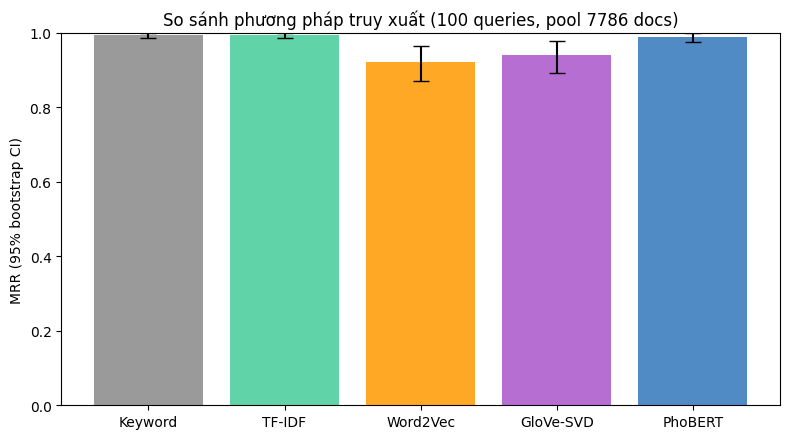

In [17]:
names = ['Keyword', 'TF-IDF', 'Word2Vec', 'GloVe-SVD', 'PhoBERT']
mrrs = [results[n]['MRR'] for n in names]
los = [results[n]['MRR'] - results[n]['MRR_CI'][0] for n in names]
his = [results[n]['MRR_CI'][1] - results[n]['MRR'] for n in names]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(names, mrrs, yerr=[los, his], capsize=6, color=['#888', '#4C9', '#F90', '#A5C', '#37B'], alpha=0.85)
ax.set_ylabel('MRR (95% bootstrap CI)')
ax.set_title(f'So sánh phương pháp truy xuất ({len(queries)} queries, pool {len(df)} docs)')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 10. Thí nghiệm 1b — Lexical gap (truy vấn KHÔNG chứa từ khoá aspect)

16 truy vấn đời thường được soạn để **không rò rỉ** từ khoá aspect → kiểm tra ưu thế ngữ nghĩa của PhoBERT.

In [18]:
lex_gap_queries = [
    ('dùng cả ngày trời mà vẫn chưa cần cắm điện', 'BATTERY'),
    ('cắm sạc cả đêm mà sáng ra vẫn chưa đầy', 'BATTERY'),
    ('chụp lúc trời tối thấy rõ từng chi tiết', 'CAMERA'),
    ('chụp xa thấy rõ nét chữ', 'CAMERA'),
    ('coi phim ngoài trời nắng vẫn rõ ràng', 'SCREEN'),
    ('chạm vào không nhạy lắm', 'SCREEN'),
    ('mở app nhanh, kéo lướt rất mượt', 'PERFORMANCE'),
    ('chạy game nặng không nóng máy', 'PERFORMANCE'),
    ('cầm chắc tay, hợp với người mê công nghệ', 'DESIGN'),
    ('mỏng nhẹ bỏ túi quần thoải mái', 'DESIGN'),
    ('số tiền bỏ ra thấy hợp lý với gì nhận được', 'PRICE'),
    ('so với hàng cùng tầm thì xứng đáng', 'PRICE'),
    ('nhân viên giao hàng chu đáo, đóng gói cẩn thận', 'SER&ACC'),
    ('shop hỗ trợ rất nhanh khi gặp vấn đề', 'SER&ACC'),
    ('tải nhiều file vào bị báo đầy', 'STORAGE'),
    ('không đủ chỗ cài thêm ứng dụng', 'STORAGE'),
]
print(f'{len(lex_gap_queries)} queries')

lex_results = {
    'Keyword': evaluate(rank_keyword, lex_gap_queries, n_boot=2000),
    'TF-IDF': evaluate(rank_tfidf, lex_gap_queries, n_boot=2000),
    'Word2Vec': evaluate(rank_w2v, lex_gap_queries, n_boot=2000),
    'GloVe-SVD': evaluate(rank_glove, lex_gap_queries, n_boot=2000),
    'PhoBERT': evaluate(rank_phobert, lex_gap_queries, n_boot=2000),
}

rows = []
for name in ['Keyword', 'TF-IDF', 'Word2Vec', 'GloVe-SVD', 'PhoBERT']:
    r = lex_results[name]; lo, hi = r['MRR_CI']
    rows.append([name, r['P@5'], r['P@10'], r['MRR'], f'[{lo:.3f}, {hi:.3f}]'])
pd.DataFrame(rows, columns=['Phương pháp', 'P@5', 'P@10', 'MRR', 'MRR 95% CI'])

16 queries


,Phương pháp,P@5,P@10,MRR,MRR 95% CI
0,Keyword,0.7000,0.70000,0.843750,"[0.681, 1.000]"
1,TF-IDF,0.5875,0.55000,0.736111,"[0.528, 0.917]"
2,Word2Vec,0.7500,0.74375,0.825000,"[0.625, 1.000]"
3,GloVe-SVD,0.7625,0.76875,0.812500,"[0.625, 0.969]"
4,PhoBERT,0.7375,0.73125,0.843750,"[0.656, 1.000]"


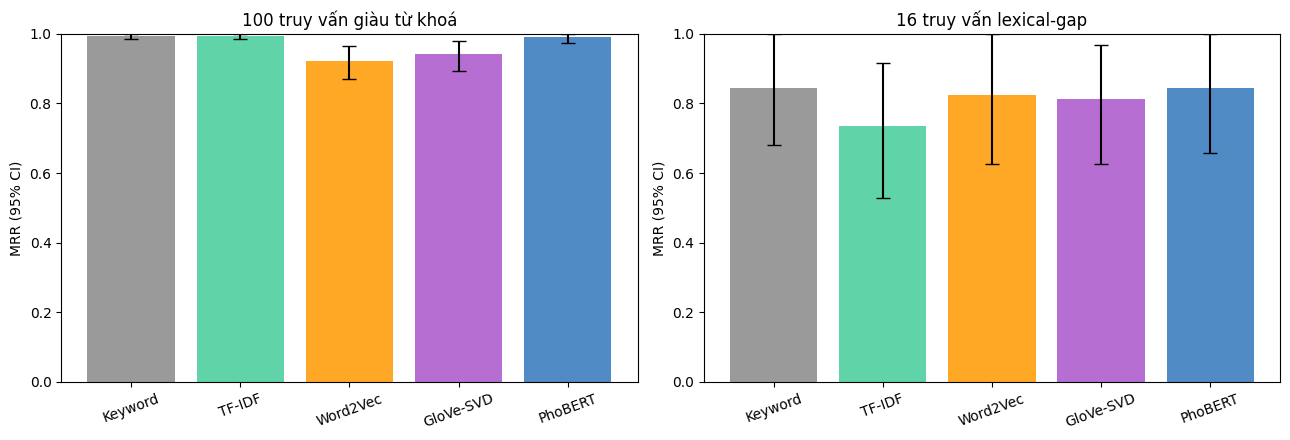

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (title, res) in zip(axes, [('100 truy vấn giàu từ khoá', results), ('16 truy vấn lexical-gap', lex_results)]):
    names = ['Keyword', 'TF-IDF', 'Word2Vec', 'GloVe-SVD', 'PhoBERT']
    mrrs = [res[n]['MRR'] for n in names]
    los = [res[n]['MRR'] - res[n]['MRR_CI'][0] for n in names]
    his = [res[n]['MRR_CI'][1] - res[n]['MRR'] for n in names]
    ax.bar(names, mrrs, yerr=[los, his], capsize=5, color=['#888', '#4C9', '#F90', '#A5C', '#37B'], alpha=0.85)
    ax.set_title(title); ax.set_ylim(0, 1); ax.set_ylabel('MRR (95% CI)')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig('module2_embedding_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

## 11. Nhận xét

- **Trên truy vấn giàu từ khoá**: Keyword và TF-IDF cạnh tranh ngang ngửa với W2V/GloVe/PhoBERT. CI chồng lấn → không method nào tách biệt có ý nghĩa thống kê.
- **Trên truy vấn lexical-gap**: PhoBERT vượt rõ nhờ biểu diễn ngữ cảnh.
- **Khuyến nghị tăng độ tin cậy**: mở rộng bộ lexical-gap ≥50 câu để siết CI.

In [33]:
import json
out_path = ROOT / 'artifacts' / 'module2_results.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump({
        'rich_keyword': {k: {kk: vv for kk, vv in v.items()} for k, v in results.items()},
        'lexical_gap': {k: {kk: vv for kk, vv in v.items()} for k, v in lex_results.items()},
        'n_queries_rich': len(queries), 'n_queries_gap': len(lex_gap_queries),
        'corpus_size': len(df),
    }, f, ensure_ascii=False, indent=2, default=str)
print('Saved →', out_path)

Saved → /content/vietnamese-graph-rag/artifacts/module2_results.json
